In [1]:
from utilities import * 
from myCGAN import MyCGAN
from myCWGAN import MyCWGAN
import pandas as pd
import numpy as np


# DATA MANAGEMENT

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 3        # Number of time steps
J = 2        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

sim.get_paths()
sim.get_pdf(n_steps_ahead=10, n_bins=3)
sim.save_binary_file('data/inputs/demo')
print(sim.paths)
print(sim.pdf)

In [ ]:
file_paths, file_pdf = sim.load_binary_file('data/inputs/demo.bin')

In [ ]:
print(file_paths)
print(file_pdf)

# MEAN AND VARIANCE

In [2]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10)

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='standardization')


conditional_gan = MyCGAN(max_epoch= 100, name = 'CGAN_mean_std')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1])
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='mean_std_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/mean_std_error_dist.csv')
print(means,'\n', std, '\n', summary)

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100, verbose=True)
pdfs

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='bins_p_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/bins_p_error_dist.csv')
print(means,'\n', std, '\n', summary)

In [ ]:
summary

## ks test 

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=1

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = val.get_paths()
pdfs= val.get_pdf(n_steps_ahead=10, n_bins=100)
bins = val.bins

In [ ]:
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.load_models()

In [4]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
preds, _ = conditional_gan.generate(mydata)

generated = np.exp(preds)


In [ ]:
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df

In [ ]:
generated_sample = generated[0]
true_sample = pdfs[0]

plot_bin_dist(true_sample, generated_sample, bins)



# CGAN BINS PROBABILITIES 


In [ ]:
# data simulation 
# example
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=1, n_bins=100)
sim.save_configuration('./models/bins/CGAN_100b.json')
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')

generator_params = {"hidden_dims": [512, 256, 256, 128]}
discriminator_params = {"hidden_dims": [512, 256, 256, 128, 64]}
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_100b')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True, **generator_params)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1], output_dim=1, **discriminator_params)
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='cgan_100b_errors.csv')


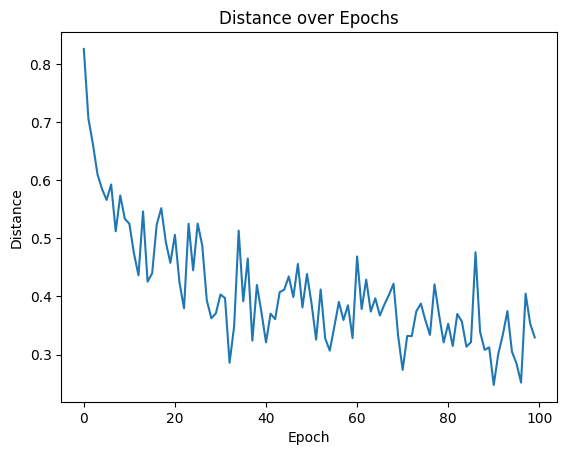

In [4]:
plot_learning_curve('generated_vs_true.csv')

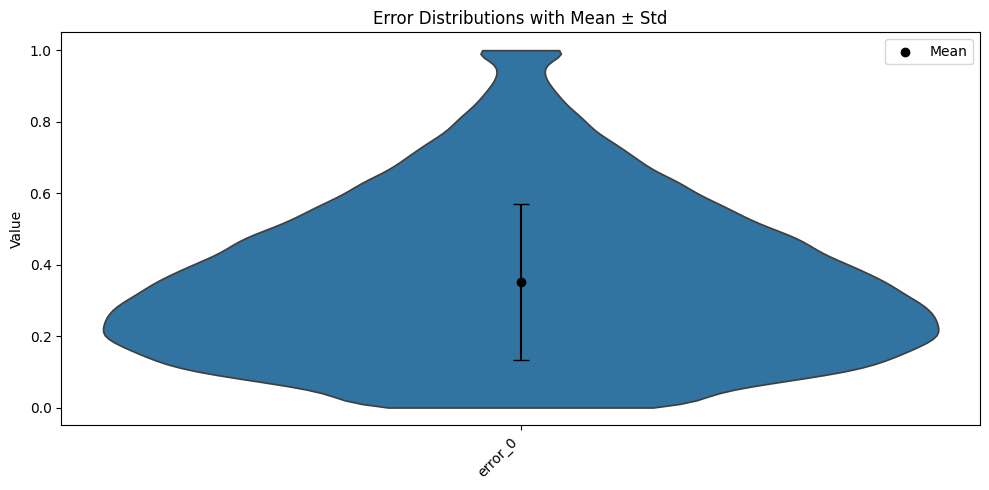

error_0    0.35127
dtype: float64 
 error_0    0.218632
dtype: float64 
             mean       std    median      skew  kurtosis  is_zero_test  \
error_0  0.35127  0.218632  0.318176  0.655748 -0.044113         False   

                               confidence_interval  
error_0  (0.34991502465302754, 0.3526252059783325)  


In [6]:
means, std, summary = analyze_error_distribution('./data/results/cgan_100b_errors.csv')
print(means,'\n', std, '\n', summary)

## KS TEST

In [22]:
# data simulation 
# example

X0_range = (0.0, 0.0)#[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = (0.0, 0.0)#[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = (0.05, 0.6)#[0.001, 0.01, 0.05, 0.1, 0.5, 0.8]
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CGAN_100b.json')
paths = val.get_paths()
pdfs = val.get_pdf(n_steps_ahead=1)
Xt = val.X_T
bins = val.bins

conditional_gan = MyCGAN(max_epoch=100, name='CGAN_100b')
conditional_gan.load_models()


Bins loaded from models\bins\CGAN_100b.json
Loaded 101 bins
CGAN config loaded from ./models\CGAN_100b_config.json
Generator loaded from ./models\CGAN_100b_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [512, 256, 256, 128], 'is_prob': True, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\CGAN_100b_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}


In [ ]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.05]
print(len(test_h0)/len(test_df))

error_metrics = get_error_metrics(pdfs, generated)
for metric_name, metric in error_metrics.items():
    print(f'the {metric_name} is: {np.mean(metric)}\n')


0.298


,p_values
1,0.849433
2,0.959366
4,0.163074
5,0.261501
6,1.000000
...,...
991,0.066181
993,0.147062
994,0.643444
997,1.000000


In [26]:
error_metrics = get_error_metrics(pdfs, generated)
for metric_name, metric in error_metrics.items():
    print(f'the {metric_name} is: {np.mean(metric)}\n')

the mae is: 0.006156041692067987

the js_distance is: 0.3430049362091364

the hellinger_distance is: 0.3067204701582432

the tv_distance is: 0.3078020846033994



In [19]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CGAN_100b.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_100b')
conditional_gan.load_models()



mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.05]
print(len(test_h0)/len(test_df))
test_h0


Bins loaded from models\bins\CGAN_100b.json
Loaded 101 bins
CGAN config loaded from ./models\CGAN_100b_config.json
Generator loaded from ./models\CGAN_100b_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [512, 256, 256, 128], 'is_prob': True, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\CGAN_100b_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
0.3333333333333333


,p_values
2,1.000000
3,0.999991


In [20]:
js_divergence = compute_js(generated, pdfs, is_log=False)
mean_js = np.mean(js_divergence)
print(f'js_divergence for each sample is {js_divergence}. The mean divergence is {mean_js}')

js_divergence for each sample is [np.float64(0.5189563647613251), np.float64(0.53662516147538), np.float64(0.05496966365717054), np.float64(0.12063693390921344), np.float64(0.6691442188344264), np.float64(0.6134917645278953)]. The mean divergence is 0.41897068452756847


In [ ]:
Xt

In [ ]:
#generated_sample = generated[-1]
#true_sample = pdfs[-1]
#plot_bin_dist(true_sample, generated_sample, bins, Xt[-1])

plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)



# CWGAN BINS PROBABILITIES

In [ ]:
# data simulation 
# example
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=1, n_bins=100)
sim.save_configuration('./models/bins/CWGAN_v0.json')
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess="log")

generator_params = {"hidden_dims": [512, 256, 256, 128], "use_batch_norm":False}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':True}
conditional_gan = MyCWGAN(max_epoch=100, name='CWGAN_v0')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True, **generator_params)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True, early_stopping_waiting=100)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='CWGAN_error_v0.csv')


In [ ]:
plot_learning_curve('wcgan_generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/CWGAN_v0.csv')
print(means,'\n', std, '\n', summary)

## KS TEST

In [27]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CWGAN_v0.json')
paths = val.get_paths()
pdfs = val.get_pdf(n_steps_ahead=1)
Xt = val.X_T
bins = val.bins

conditional_gan = MyCGAN(max_epoch=100, name='CWGAN_v0')
conditional_gan.load_models()



Bins loaded from models\bins\CWGAN_v0.json
Loaded 101 bins
CGAN config loaded from ./models\CWGAN_v0_config.json
Generator loaded from ./models\CWGAN_v0_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [512, 256, 256, 128], 'is_prob': True, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\CWGAN_v0_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}


In [28]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print(len(test_h0)/len(test_df))
test_h0


0.412


,p_values
0,0.197153
1,0.999998
3,1.000000
5,0.095525
6,1.000000
...,...
989,0.417486
994,0.764545
995,0.466718
997,1.000000


In [30]:
error_metrics = get_error_metrics(pdfs, generated)
for metric_name, metric in error_metrics.items():
    print(f'the {metric_name} is: {np.mean(metric)}\n')

the mae is: 0.00545012549837964

the js_distance is: 0.3050277923835073

the hellinger_distance is: 0.2711517301244348

the tv_distance is: 0.27250627491898194



In [ ]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CWGAN_v0.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins


conditional_gan = MyCGAN(max_epoch=100, name='CWGAN_v0')
conditional_gan.load_models()


Bins loaded from models\bins\CWGAN_v0.json
Loaded 101 bins
CGAN config loaded from ./models\CWGAN_v0_config.json
Generator loaded from ./models\CWGAN_v0_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [512, 256, 256, 128], 'is_prob': True, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\CWGAN_v0_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}


In [10]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print(len(test_h0)/len(test_df))
test_h0


0.5


,p_values
0,1.000000
1,0.514957
2,1.000000


In [11]:
js_divergence = compute_js(generated, pdfs, is_log=False)
mean_js = np.mean(js_divergence)
print(f'js_divergence for each sample is {js_divergence}. The mean divergence is {mean_js}')

js_divergence for each sample is [np.float64(0.00018151219131523163), np.float64(0.14383606839277413), np.float64(0.03836084454393223), np.float64(0.24365957523197834), np.float64(0.9241381303515491), np.float64(0.23197149922807714)]. The mean divergence is 0.2636912716566044


In [ ]:
Xt

In [ ]:
#generated_sample = generated[-1]
#true_sample = pdfs[-1]
#plot_bin_dist(true_sample, generated_sample, bins, Xt[-1])

plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)



# FORGAN simple

In [44]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forgan_simple.json')

Bins saved to models\bins\forgan_simple.json


In [ ]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {"hidden_dims": [512, 256, 128, 64], "use_batch_norm":True}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':False}
conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple', z_noise_dim=64)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True, distance_metric='mse')
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='forgan_simple.csv')


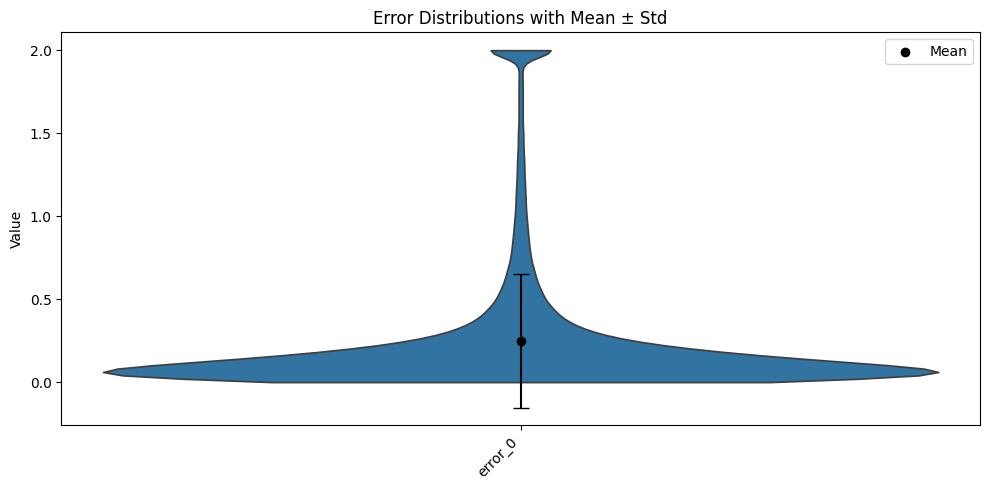

error_0    0.247726
dtype: float64 
 error_0    0.401025
dtype: float64 
              mean       std    median      skew   kurtosis  is_zero_test  \
error_0  0.247726  0.401025  0.112539  3.155226  10.000242         False   

                                confidence_interval  
error_0  (0.24523996364248796, 0.25021109187599544)  


In [3]:
means, std, summary = analyze_error_distribution('./data/results/forgan_simple.csv')
print(means,'\n', std, '\n', summary)

## ks test

In [2]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

# model 
conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple')
conditional_gan.load_models()


mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)
true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))




CGAN config loaded from ./models\forgan_simple_config.json
Generator loaded from ./models\forgan_simple_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_simple_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (1000, 1000)
percentage of acceptance of KS test:  0.2725450901803607
js_distance 0.5730828547985307
hellinger_distance 0.5301088773965936
tv_distance 0.5529258460991782
emd_distance 0.027409322263530767


In [4]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/forgan_simple.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = val.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple')
conditional_gan.load_models()



mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)



true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))


Bins loaded from models\bins\forgan_simple.json
Loaded 101 bins
CGAN config loaded from ./models\forgan_simple_config.json
Generator loaded from ./models\forgan_simple_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_simple_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (1000, 1000)
percentage of acceptance of KS test:  0.273


c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\utilities.py:132: RuntimeWarning: invalid value encountered in divide
  generated_discretized_pdfs.append(hist_generated/hist_generated.sum())


js_distance nan
hellinger_distance nan
tv_distance nan
emd_distance nan


In [6]:
filepath = "models/forgan_simple_discriminator.pth"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(filepath, map_location=device)
state_dict = checkpoint['model_state_dict']
# Remap 'layer.' to 'layers.' in keys
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('layer.'):
        new_k = k.replace('layer.', 'layers.')
    else:
        new_k = k
    new_state_dict[new_k] = v
checkpoint['model_state_dict'] = new_state_dict
torch.save(checkpoint, filepath)

In [3]:
# data simulation 
# example


X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/forgan_simple.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = val.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple')
conditional_gan.load_models()



mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)



true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))

Bins loaded from models\bins\forgan_simple.json
Loaded 101 bins
CGAN config loaded from ./models\forgan_simple_config.json
Generator loaded from ./models\forgan_simple_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_simple_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (6, 1000)
percentage of acceptance of KS test:  0.16666666666666666
js_distance 0.6389803718953667
hellinger_distance 0.5996931351377973
tv_distance 0.6204337645019741
emd_distance 0.027803893649224014


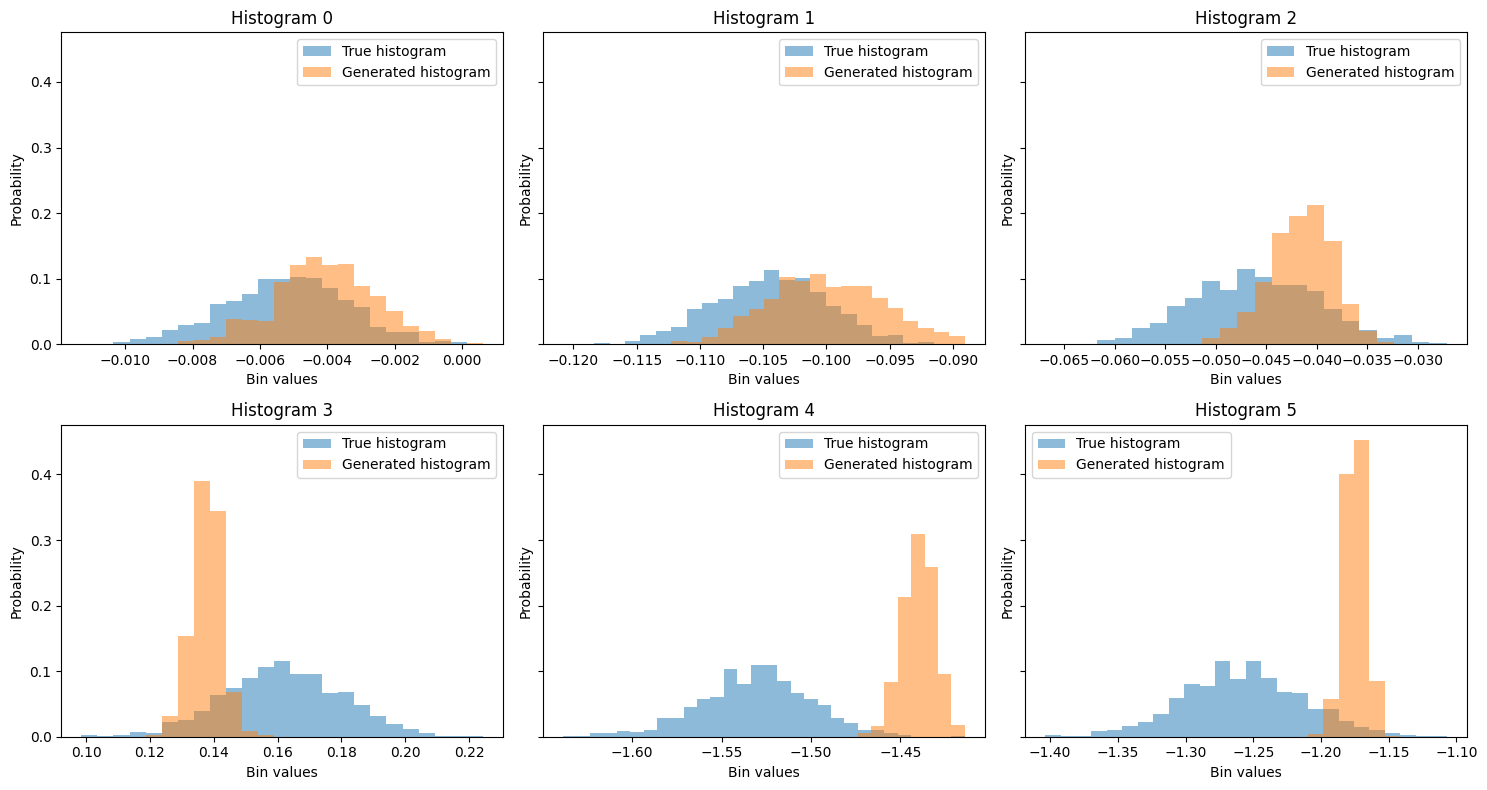

In [5]:
plot_bin_dist(true_pdfs, generated_pdfs, bins_values=bin_edges_list)


# FORGAN

In [ ]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forgan_v3.json')

Bins saved to models\bins\forgan_v3.json


In [ ]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {"hidden_dims": [512, 256, 128, 64], "use_batch_norm":False}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':True}
conditional_gan = MyCWGAN(max_epoch=100, name='forgan_v3', z_noise_dim=64)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True, early_stopping_waiting=100, distance_metric='mse')
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='forgan_v3.csv')


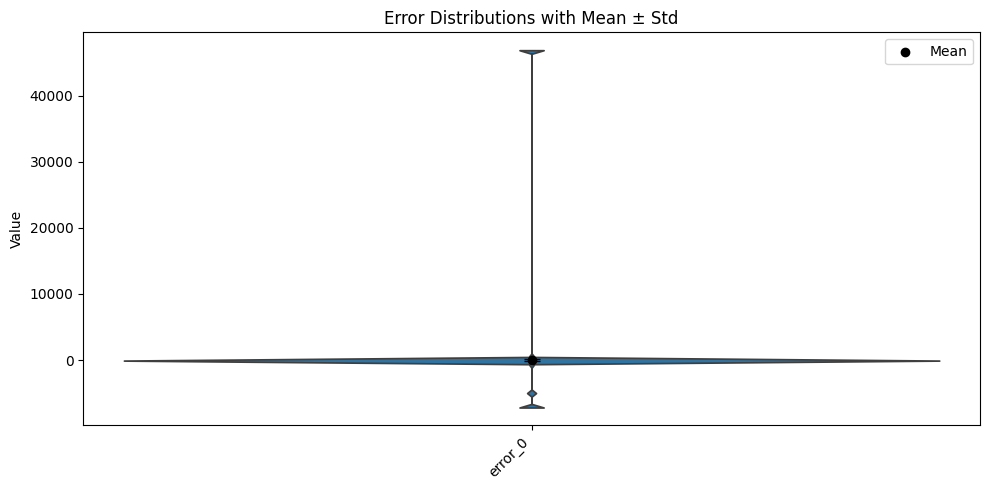

error_0    0.33918
dtype: float64 
 error_0    153.497078
dtype: float64 
             mean         std    median        skew      kurtosis  \
error_0  0.33918  153.497078 -0.026294  284.653331  86965.459361   

         is_zero_test                        confidence_interval  
error_0          True  (-0.6121983947104437, 1.2905591652713824)  


In [10]:
means, std, summary = analyze_error_distribution('./data/results/forgan_v3.csv')
print(means,'\n', std, '\n', summary)

## KS test 

In [3]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

sim.load_configuration('./models/bins/forgan_v3.json')
trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

# model 
conditional_gan = MyCWGAN(max_epoch=100, name='forgan_v3')
conditional_gan.load_models()


mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)

true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))




Bins loaded from models\bins\forgan_v3.json
Loaded 101 bins
CGAN config loaded from ./models\forgan_v3_config.json
Generator loaded from ./models\forgan_v3_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_v3_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (1000, 1000)
percentage of acceptance of KS test:  0.556
js_distance 0.38706390705611093
hellinger_distance 0.3441411742552233
tv_distance 0.3588618783792065
emd_distance 0.01458814577409015


### visual

In [6]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

# model 
conditional_gan = MyCWGAN(max_epoch=100, name='forgan_v3')
conditional_gan.load_models()


mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)

true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))


CGAN config loaded from ./models\forgan_v3_config.json
Generator loaded from ./models\forgan_v3_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_v3_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (6, 1000)
percentage of acceptance of KS test:  0.8333333333333334
js_distance 0.380222721797382
hellinger_distance 0.3380865661986996
tv_distance 0.34390379554941664
emd_distance 0.018080063454211922


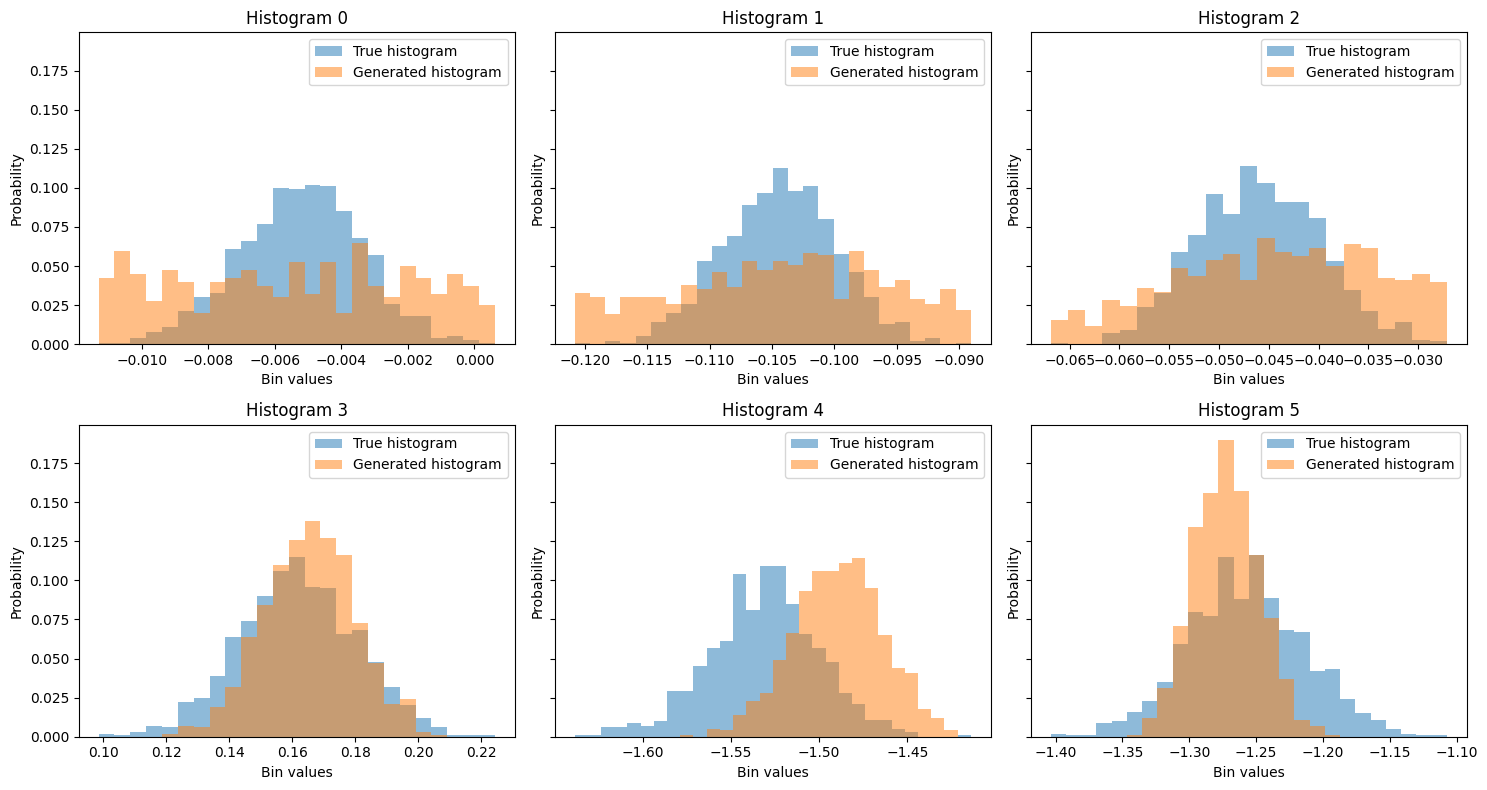

In [7]:
plot_bin_dist(true_pdfs, generated_pdfs, bins_values=bin_edges_list)

# LSTM FORGAN

In [2]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forgan_rnn.json')

Bins saved to models\bins\forgan_rnn.json


In [ ]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {'rnn_layer':'gru'}
critic_params = {'use_layer_norm':True, 'rnn_layer':'gru'}
conditional_gan = MyCWGAN(max_epoch=100, name='forgan_rnn', z_noise_dim=64)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1],
                              hidden_dim_rnn=8, **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1],
                                  hidden_dim_rnn=8, **critic_params)
conditional_gan.train(mydata, save_history=True, early_stopping_waiting=100, distance_metric='mse')
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='forgan_rnn.csv')


# MONTECARLO CGAN

In [14]:
# data simulation 
# example
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=1, n_bins=100, mc_sims=1000)
sim.save_configuration('./models/bins/CGAN_100b_mc.json')
pdfs.shape

Bins saved to models\bins\CGAN_100b_mc.json


(100000, 100)

In [ ]:
# data simulation 
# example
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim_theory = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths_theory = sim_theory.get_paths()
pdfs_theory= sim_theory.get_pdf(n_steps_ahead=1, n_bins=100)
pdfs_theory.shape

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100000, 100))

In [4]:
print(sim_theory.sigma)

[0.60888931 0.29007551 0.77685144 0.71556569 0.62492296 0.16376458
 0.37870959 0.04460497 0.1318887  0.54960867]


In [5]:
print(sim.sigma)

[0.60888931 0.29007551 0.77685144 0.71556569 0.62492296 0.16376458
 0.37870959 0.04460497 0.1318887  0.54960867]


In [38]:
result = compute_js(pdfs, pdfs_theory)
print(np.nanmean(result))


c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\.venv\Lib\site-packages\scipy\spatial\distance.py:1388: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)


0.0009466155455870805


In [37]:
# Find indices where result is NaN
nan_indices = np.where(np.isnan(result))[0]

print(f"Number of NaN values in result: {len(nan_indices)}")
print(nan_indices)



Number of NaN values in result: 24
[  957  5536  8660  8937  9735 10381 29803 36006 36272 37888 40188 43960
 48147 55350 56262 58381 61665 61824 63793 78157 78653 88716 90166 94417]


In [35]:
pdfs[9735]


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [36]:
pdfs_theory[9735]

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')

generator_params = {"hidden_dims": [512, 256, 256, 128]}
discriminator_params = {"hidden_dims": [512, 256, 256, 128, 64]}
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_100b_mc')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True, **generator_params)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1], output_dim=1, **discriminator_params)
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='CGAN_100b_mc_errors.csv')


In [ ]:
# data simulation 
# example

X0_range = (0.0, 0.0)#[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = (0.0, 0.0)#[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = (0.05, 0.6)#[0.001, 0.01, 0.05, 0.1, 0.5, 0.8]
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CGAN_100b_mc.json')
paths = val.get_paths()
pdfs = val.get_pdf(n_steps_ahead=1)
Xt = val.X_T
bins = val.bins

conditional_gan = MyCGAN(max_epoch=100, name='CGAN_100b_mc')
conditional_gan.load_models()


In [5]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.05]
print(len(test_h0)/len(test_df))

error_metrics = get_error_metrics(pdfs, generated)
for metric_name, metric in error_metrics.items():
    print(f'the {metric_name} is: {np.mean(metric)}\n')


0.233
the mae is: 0.008042155128739154

the js_distance is: 0.43096207103428597

the hellinger_distance is: 0.3933919109099275

the tv_distance is: 0.4021077564369577



# MONTECARLO CWGAN

In [6]:
# data simulation 
# example
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=1, n_bins=100, mc_sims=1000)
sim.save_configuration('./models/bins/CWGAN_v0_mc.json')
pdfs

Bins saved to models\bins\CWGAN_v0_mc.json


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100000, 100))

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess="log")

generator_params = {"hidden_dims": [512, 256, 256, 128], "use_batch_norm":False}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':True}
conditional_gan = MyCWGAN(max_epoch=100, name='CWGAN_v0_mc')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True, **generator_params)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True, early_stopping_waiting=100)
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='CWGAN_error_v0_mc.csv')


In [39]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CWGAN_v0_mc.json')
paths = val.get_paths()
pdfs = val.get_pdf(n_steps_ahead=1)
Xt = val.X_T
bins = val.bins

conditional_gan = MyCGAN(max_epoch=100, name='CWGAN_v0_mc')
conditional_gan.load_models()



Bins loaded from models\bins\CWGAN_v0_mc.json
Loaded 101 bins
CGAN config loaded from ./models\CWGAN_v0_mc_config.json
Generator loaded from ./models\CWGAN_v0_mc_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [512, 256, 256, 128], 'is_prob': True, 'use_batch_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
Discriminator loaded from ./models\CWGAN_v0_mc_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}


In [40]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print(len(test_h0)/len(test_df))

error_metrics = get_error_metrics(pdfs, generated)
for metric_name, metric in error_metrics.items():
    print(f'the {metric_name} is: {np.mean(metric)}\n')


0.018
the mae is: 0.01895663309848514

the js_distance is: 0.9512796172339649

the hellinger_distance is: 0.9452832776152071

the tv_distance is: 0.9478316549242572



In [ ]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CWGAN_v0_mc.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins


conditional_gan = MyCGAN(max_epoch=100, name='CWGAN_v0_mc')
conditional_gan.load_models()



mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.05]
print(len(test_h0)/len(test_df))
test_h0


Bins loaded from models\bins\CWGAN_v0_mc.json
Loaded 101 bins


ValueError: operands could not be broadcast together with shapes (6,253) (6,) 

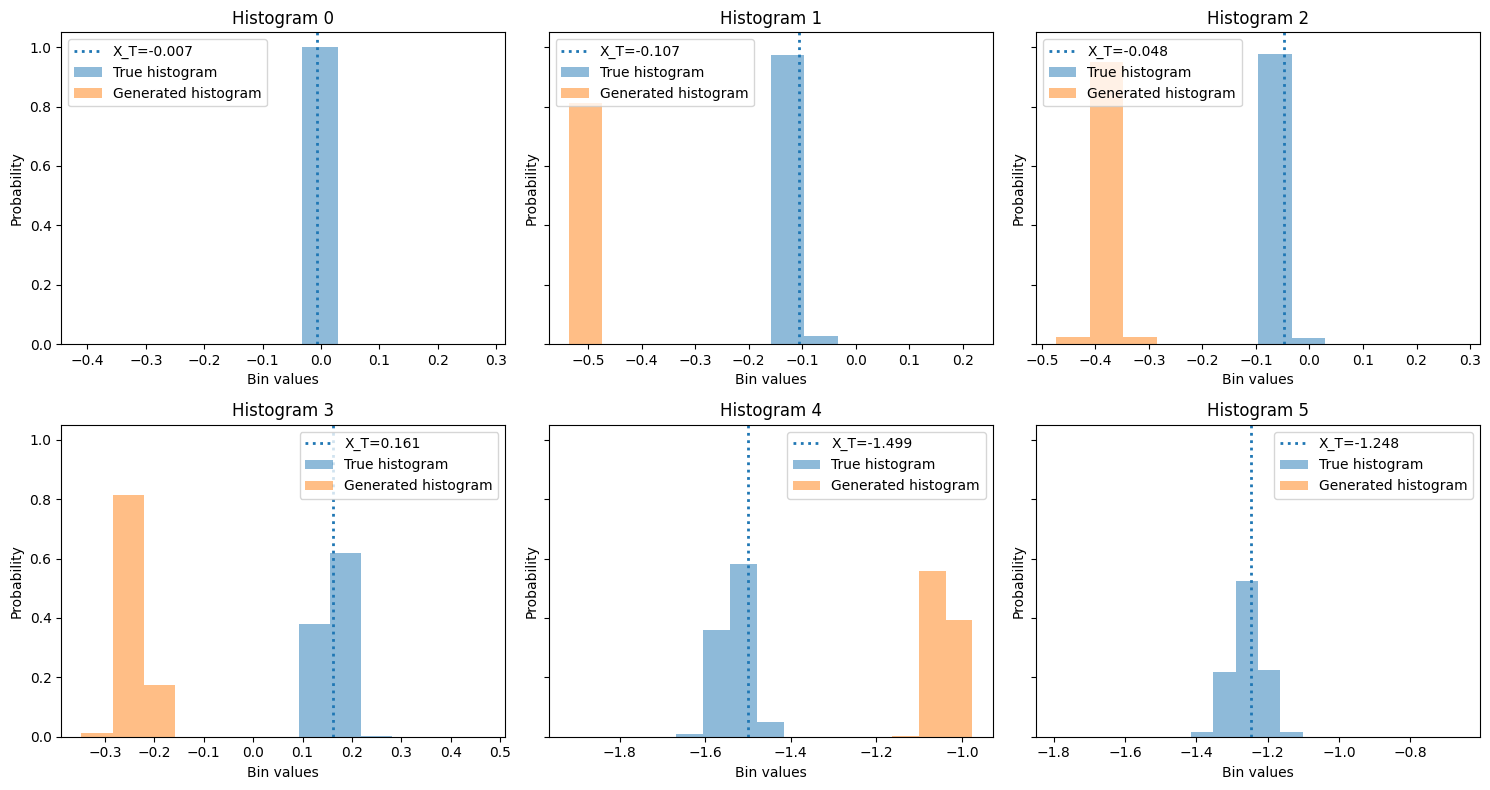

In [42]:
#generated_sample = generated[-1]
#true_sample = pdfs[-1]
#plot_bin_dist(true_sample, generated_sample, bins, Xt[-1])

plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)



# MONTECARLO FORGAN 


In [3]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)
sim.save_configuration('./models/bins/forgan_mc.json')

Bins saved to models\bins\forgan_mc.json


In [ ]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {"hidden_dims": [512, 256, 128, 64], "use_batch_norm":True}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':False}
conditional_gan = MyCGAN(max_epoch=100, name='forgan_mc', z_noise_dim=64)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True, distance_metric='mse')
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='forgan_mc.csv')


In [5]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/forgan_mc.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins

conditional_gan = MyCGAN(max_epoch=100, name='forgan_mc')
conditional_gan.load_models()



mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = bins)



p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print(len(test_h0)/len(test_df))

error_metrics = get_error_metrics(pdfs, generated)
for metric_name, metric in error_metrics.items():
    print(f'the {metric_name} is: {np.mean(metric)}\n')



Bins loaded from models\bins\forgan_mc.json
Loaded 101 bins
CGAN config loaded from ./models\forgan_mc_config.json
Generator loaded from ./models\forgan_mc_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_mc_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (1000, 1000)
0.383
the mae is: 0.007589874001170887

the js_distance is: 0.4184896413575456

the hellinger_distance is: 0.3935592652791237

the tv_distance is: 0.3794937000585443



# MONTECARLO FORWGAN

In [6]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)
sim.save_configuration('./models/bins/forwgan_mc.json')

Bins saved to models\bins\forwgan_mc.json


In [ ]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {"hidden_dims": [512, 256, 128, 64], "use_batch_norm":False}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':True}
conditional_gan = MyCWGAN(max_epoch=100, name='forwgan_mc', z_noise_dim=64)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True, early_stopping_waiting=100, distance_metric='mse')
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='forwgan_mc.csv')


In [7]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/forwgan_mc.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins

conditional_gan = MyCWGAN(max_epoch=100, name='forwgan_mc')
conditional_gan.load_models()




mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = bins)


p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print(len(test_h0)/len(test_df))

error_metrics = get_error_metrics(pdfs, generated)
for metric_name, metric in error_metrics.items():
    print(f'the {metric_name} is: {np.mean(metric)}\n')






Bins loaded from models\bins\forwgan_mc.json
Loaded 101 bins
CGAN config loaded from ./models\forwgan_mc_config.json
Generator loaded from ./models\forwgan_mc_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
Discriminator loaded from ./models\forwgan_mc_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (1000, 1000)
0.02
the mae is: 0.014638741243617154

the js_distance is: 0.7440201996032215

the hellinger_distance is: 0.7122638828865409

the tv_distance is: 0.7319370621808577

